Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Load Dataset

In [5]:
apps = pd.read_csv('apps.csv')
reviews = pd.read_csv('user_reviews.csv')
apps.head()
reviews.head()
apps.info()
reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #

Remove Duplicates

In [ ]:
apps.drop_duplicates(inplace=True)


Handle Missing Values

In [16]:
apps.isnull().sum()

Unnamed: 0        0
App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

Remove rows with missing ratings:

In [10]:
apps = apps.dropna(subset=['Rating'])

Fill missing values:

In [12]:
apps.fillna(0, inplace=True)

Clean Installs Column

In [14]:
apps['Installs'] = apps['Installs'].str.replace(',', '')
apps['Installs'] = apps['Installs'].str.replace('+', '')
apps['Installs'] = apps['Installs'].astype(int)

Clean Price Column

In [17]:
apps['Price'] = apps['Price'].str.replace('$', '')
apps['Price'] = apps['Price'].astype(float)

Clean Size Column

In [18]:
def convert_size(size):
    if 'M' in str(size):
        return float(size.replace('M', ''))
    elif 'k' in str(size):
        return float(size.replace('k', '')) / 1024
    else:
        return np.nan

apps['Size'] = apps['Size'].apply(convert_size)

Exploratory Data Analysis (EDA)
Category Distribution

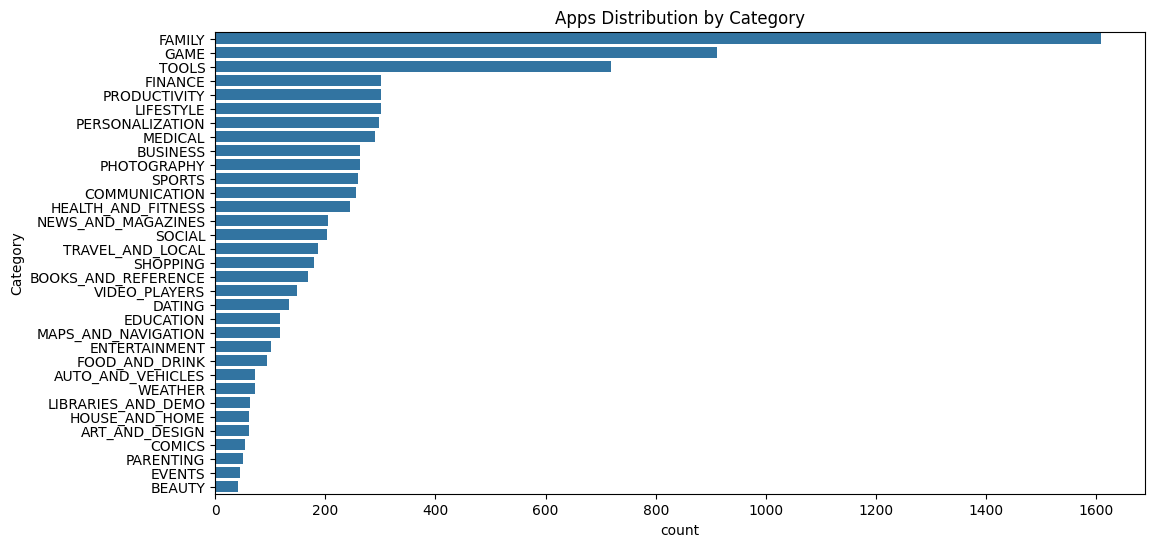

In [19]:
plt.figure(figsize=(12,6))
sns.countplot(y='Category', data=apps,
              order=apps['Category'].value_counts().index)
plt.title('Apps Distribution by Category')
plt.show()

Ratings Analysis

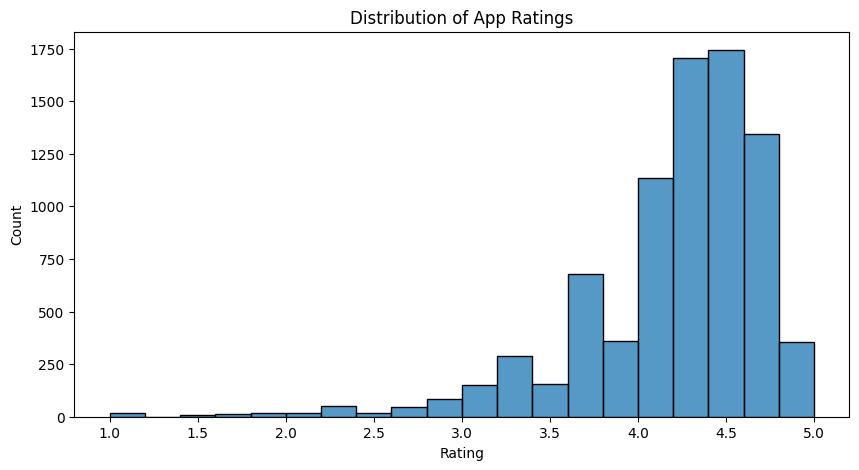

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(apps['Rating'], bins=20)
plt.title('Distribution of App Ratings')
plt.show()

Free vs Paid Apps

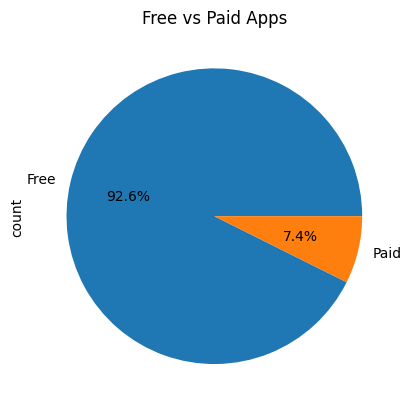

In [21]:
apps['Type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Free vs Paid Apps')
plt.show()

Installs Analysis

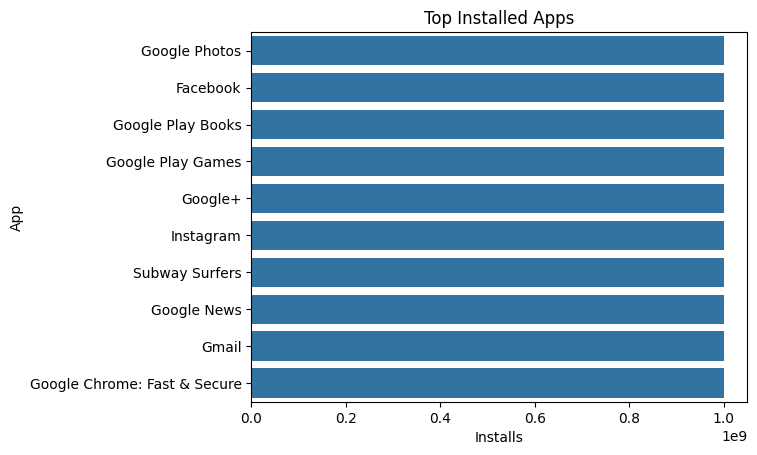

In [23]:
top_apps = apps.sort_values(by='Installs', ascending=False).head(10)

sns.barplot(x='Installs', y='App', data=top_apps)
plt.title('Top Installed Apps')
plt.show()

Price Analysis

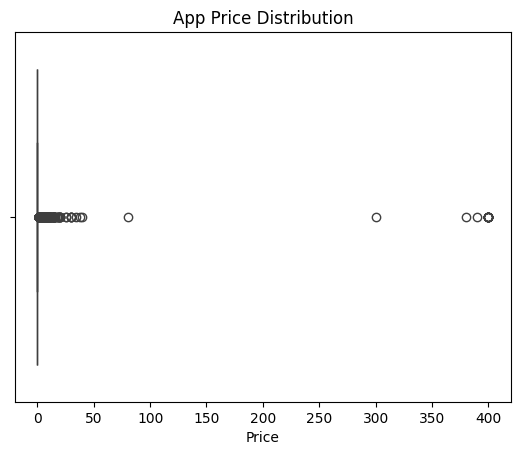

In [24]:
sns.boxplot(x=apps['Price'])
plt.title('App Price Distribution')
plt.show()

Correlation Heatmap

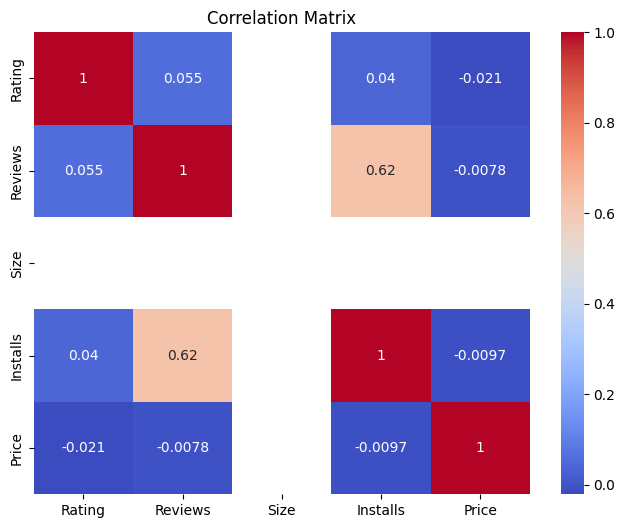

In [25]:
corr = apps[['Rating','Reviews','Size',
             'Installs','Price']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Sentiment Analysis

In [26]:
reviews['Sentiment'].value_counts()

Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64

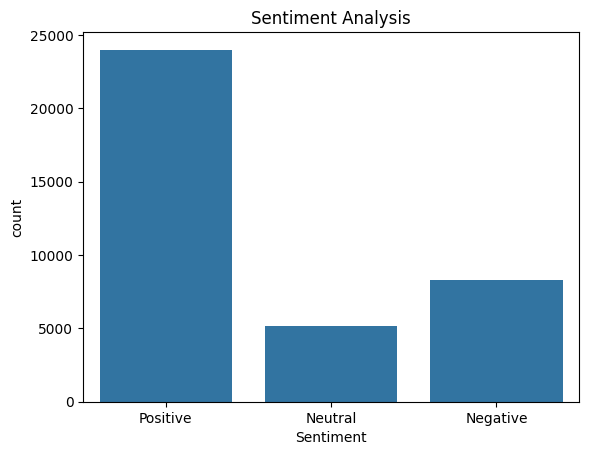

In [27]:
sns.countplot(x='Sentiment', data=reviews)
plt.title('Sentiment Analysis')
plt.show()

WordCloud Visualization

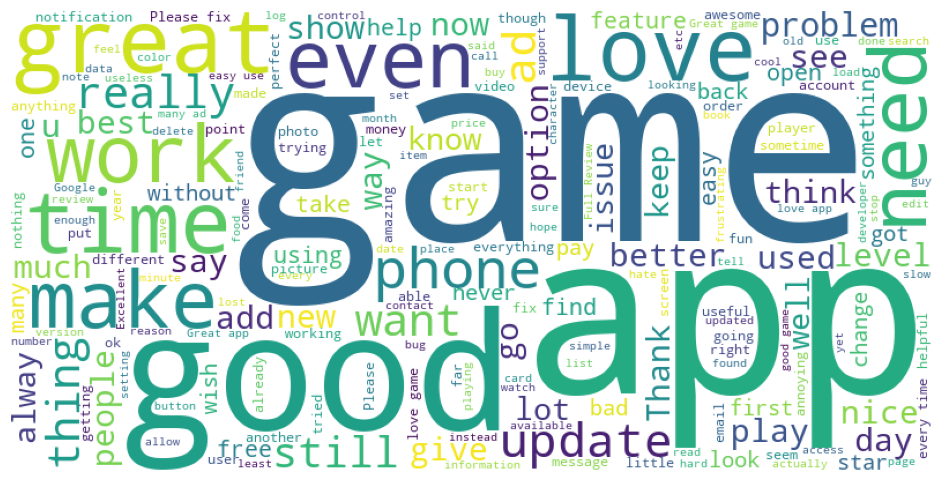

In [30]:
from wordcloud import WordCloud

text = " ".join(reviews['Translated_Review'].dropna())

wordcloud = WordCloud(width=800,
                      height=400,
                      background_color='white').generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

Interactive Plotly Charts

In [32]:
fig = px.scatter(apps,
                 x='Rating',
                 y='Installs',
                 color='Category',
                 title='Ratings vs Installs')

plt.show()

Save Clean Dataset

In [33]:
apps.to_csv("cleaned_apps.csv", index=False)
reviews.to_csv("cleaned_reviews.csv", index=False)